# Random Forest

## Import libraries

In [91]:
import ccxt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

## Constants

In [92]:
TIMEFRAME_DICT = {
    "1m": 60 * 1000,
    "5m": 5 * 60 * 1000,
    "15m": 15 * 60 * 1000,
    "1h": 60 * 60 * 1000,
    "1d": 24 * 60 * 60 * 1000,
}

FREQ_DICT = {
    "1m": "T",
    "5m": "5T",
    "15m": "15T",
    "1h": "h",
    "1d": "D",
}

Y_OUTPUT_DICT = {
    "log_return_close": False,
    "bin_return_close": True,
    "bin_return_d2d_close": True,
}

In [93]:
CLIENT = ccxt.binance()
TICKER = "BTC/USDT"
END_DATE = CLIENT.parse8601("2026-03-31T20:00:00Z")
START_DATE = CLIENT.parse8601("2023-11-03T20:00:00Z")
TIMEFRAME = "1h"
LAGS_NUM = 240
TRAIN_TEST_SPLIT_RATIO = 0.7
N_ESTIMATORS = 500
MAX_DEPTH = 6
MIN_SAMPLES_LEAF = 5
MAX_FEATURES = "sqrt"
RANDOM_STATE = 42
N_JOBS = -1
SCALER_BOOLEAN = False
OUTPUT_VALUE = 'bin_return_d2d_close'
BINARY_CLASSIFICATION = Y_OUTPUT_DICT[OUTPUT_VALUE]

## Fetching data

In [94]:
def fetch_data(client, ticker, start_date, end_date, timeframe):
    data = []
    while start_date < end_date:
        limit = 1000 if end_date - start_date >= TIMEFRAME_DICT[timeframe] * 1000 else (end_date - start_date) // (TIMEFRAME_DICT[timeframe])
        if limit <= 0:
            break
        data = data + client.fetch_ohlcv(
            ticker,
            timeframe=timeframe,
            since=start_date,
            limit=limit,
        )
        
        start_date = data[-1][0] + TIMEFRAME_DICT[timeframe] - 1 # -1 to avoid duplicates
    return data

def preprocess_data(data):
    data = pd.DataFrame(
        data,
        columns=["Date", "Open", "High", "Low", "Close", "Volume"]
    )
    # data = data.where(data["Date"] <= END_DATE + 4 * TIMEFRAME_DICT["1h"]).dropna()
    data["Date"] = pd.to_datetime(data["Date"], unit="ms")
    data = data.set_index("Date")
    return data

In [95]:
data = fetch_data(CLIENT, TICKER, START_DATE, END_DATE, TIMEFRAME)
data = preprocess_data(data)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2023-11-03 20:00:00,34530.71,34659.66,34485.65,34593.90,1046.24789
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035


### Verifying continuous of data

In [96]:
all_dates = pd.date_range(start=data.index.min(), end=data.index.max(), freq=FREQ_DICT[TIMEFRAME])
missing = all_dates.difference(data.index)
print(len(missing), missing)   # 0 => none missing dates

0 DatetimeIndex([], dtype='datetime64[ms]', freq='h')


## Processing data

In [97]:
data['log_return_close'] = np.log(data['Close'] / data['Close'].shift(1))
data['return_close'] = data['Close'] / data['Close'].shift(1) - 1
data['bin_return_close'] = (data['log_return_close'] > 0).astype(int)
data['bin_return_d2d_close'] = (data['log_return_close'] > data['log_return_close'].shift(1)).astype(int)

In [98]:
data = data.dropna()
data.head()

,Open,High,Low,Close,Volume,log_return_close,return_close,bin_return_close,bin_return_d2d_close
Date,,,,,,,,,
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031,0.000203,0.000203,1,0
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337,0.000786,0.000786,1,1
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032,0.002556,0.002560,1,1
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035,-0.000580,-0.000580,0,0
2023-11-04 01:00:00,34696.66,34786.68,34632.47,34768.15,724.86868,0.002059,0.002061,1,1


## Splitting data

In [99]:
X = data[['log_return_close', 'return_close']].copy()
y = data[['log_return_close', 'return_close', 'bin_return_close', 'bin_return_d2d_close']].copy()

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1-TRAIN_TEST_SPLIT_RATIO, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, shuffle=False)
X_backtest, y_backtest = X_test.copy(), y_test.copy()

Overall probability of bin_return_d2d_close being the same as bin_return_close:
0.774


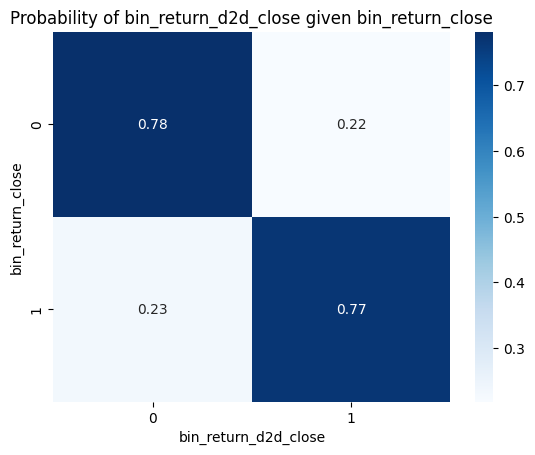

In [101]:
probs = pd.crosstab(
    y_train['bin_return_close'],
    y_train['bin_return_d2d_close'],
    normalize='index'
)
overall_prob = (y_train['bin_return_close'] == y_train['bin_return_d2d_close']).mean()
print("Overall probability of bin_return_d2d_close being the same as bin_return_close:\n{:.3f}".format(overall_prob))
sns.heatmap(probs, annot=True, fmt=".2f", cmap="Blues")
plt.title("Probability of bin_return_d2d_close given bin_return_close")
plt.xlabel("bin_return_d2d_close")
plt.ylabel("bin_return_close")
plt.show()

In [102]:
def generate_lags(X, y, lags_num, output_value, feature_scaler=None, target_scaler=None, fit_scalers=False):
    X_values = X['log_return_close'].values.reshape(-1, 1)
    y_values = y[output_value].values.reshape(-1, 1)

    if feature_scaler is not None:
        X_values = feature_scaler.fit_transform(X_values) if fit_scalers else feature_scaler.transform(X_values)
    if target_scaler is not None and not BINARY_CLASSIFICATION:
        y_values = target_scaler.fit_transform(y_values) if fit_scalers else target_scaler.transform(y_values)

    X_values = X_values.flatten()
    y_values = y_values.flatten()
    X_return = []
    y_return = []

    for i in range(lags_num, len(X_values)):
        X_return.append(X_values[i-lags_num:i])
        y_return.append(y_values[i])

    return np.array(X_return), np.array(y_return)


In [103]:
feature_scaler = StandardScaler() if SCALER_BOOLEAN else None
target_scaler = StandardScaler() if SCALER_BOOLEAN and not BINARY_CLASSIFICATION else None

X_train, y_train = generate_lags(X_train, y_train, LAGS_NUM, OUTPUT_VALUE, feature_scaler, target_scaler, fit_scalers=True)
X_val, y_val = generate_lags(X_val, y_val, LAGS_NUM, OUTPUT_VALUE, feature_scaler, target_scaler)
X_test, y_test = generate_lags(X_test, y_test, LAGS_NUM, OUTPUT_VALUE, feature_scaler, target_scaler)


## Building and training model

In [104]:
common_params = {
    'n_estimators': N_ESTIMATORS,
    'max_depth': MAX_DEPTH,
    'min_samples_leaf': MIN_SAMPLES_LEAF,
    'max_features': MAX_FEATURES,
    'random_state': RANDOM_STATE,
    'n_jobs': N_JOBS,
}

if BINARY_CLASSIFICATION:
    model = RandomForestClassifier(**common_params)
else:
    model = RandomForestRegressor(**common_params)

print(model)

RandomForestClassifier(max_depth=6, min_samples_leaf=5, n_estimators=500,
                       n_jobs=-1, random_state=42)


In [105]:
print("Binary classification" if BINARY_CLASSIFICATION else "Regression")
# Random Forest has no boosting early stopping. Fit only the training split,
# matching XGBoost; use validation to report performance, without refitting on it.
model.fit(X_train, y_train)
val_pred = model.predict(X_val)

if BINARY_CLASSIFICATION:
    print("Validation classification report")
    print(classification_report(y_val, val_pred, zero_division=0))
else:
    val_true = y_val.copy()
    if target_scaler is not None:
        val_pred = target_scaler.inverse_transform(val_pred.reshape(-1, 1)).ravel()
        val_true = target_scaler.inverse_transform(val_true.reshape(-1, 1)).ravel()
    print(f"Validation MAE: {mean_absolute_error(val_true, val_pred):.6f}")
    print(f"Validation RMSE: {np.sqrt(mean_squared_error(val_true, val_pred)):.6f}")

Binary classification
Validation classification report
              precision    recall  f1-score   support

           0       0.76      0.74      0.75      1478
           1       0.74      0.76      0.75      1446

    accuracy                           0.75      2924
   macro avg       0.75      0.75      0.75      2924
weighted avg       0.75      0.75      0.75      2924



## Verifying model

In [106]:
y_pred = model.predict(X_test)

if not BINARY_CLASSIFICATION and target_scaler is not None:
    y_pred = target_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_test = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


In [107]:
print(y_test[:10])
print(y_pred[:10])


[1 1 0 0 1 0 0 1 0 1]
[1 0 0 0 1 0 1 1 0 0]


In [108]:
if BINARY_CLASSIFICATION:
    print(classification_report(y_test, y_pred, digits=4))
else:
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    directional_accuracy = np.mean((y_pred > 0) == (y_test > 0))
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"Directional accuracy: {directional_accuracy:.4f}")


              precision    recall  f1-score   support

           0     0.7602    0.7407    0.7503      1485
           1     0.7395    0.7590    0.7491      1440

    accuracy                         0.7497      2925
   macro avg     0.7499    0.7499    0.7497      2925
weighted avg     0.7500    0.7497    0.7498      2925



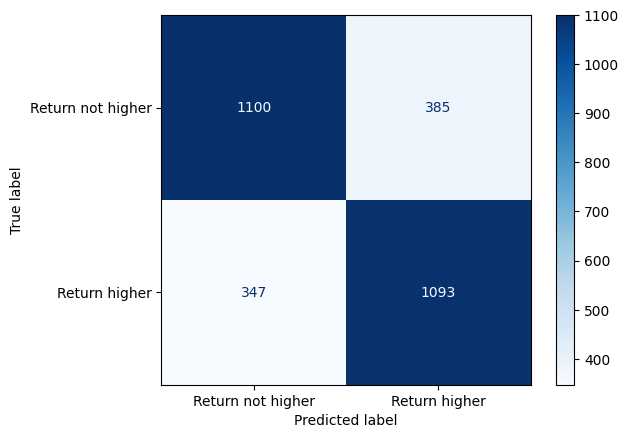

In [109]:
if BINARY_CLASSIFICATION:
    labels = ["Return not higher", "Return higher"] if OUTPUT_VALUE == 'bin_return_d2d_close' else ["Down / flat", "Up"]
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=[0, 1], cmap="Blues", display_labels=labels)
    plt.show()
else:
    plt.figure(figsize=(12, 6))
    plt.plot(y_test, label="True")
    plt.plot(y_pred, label="Predicted")
    plt.title(f"RandomForest predictions for {OUTPUT_VALUE}")
    plt.xlabel("Test sample")
    plt.ylabel(OUTPUT_VALUE)
    plt.legend()
    plt.show()

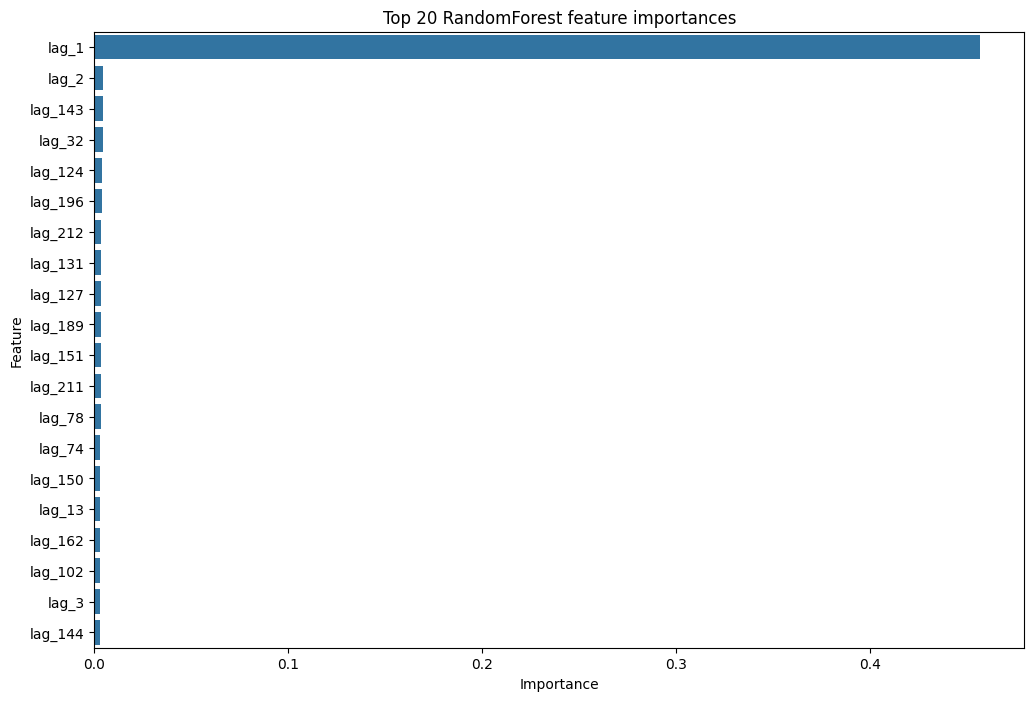

In [110]:
# generate_lags orders each window from the oldest return to the newest.
feature_columns = [f"lag_{lag}" for lag in range(LAGS_NUM, 0, -1)]
feature_importance = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance.head(20).values, y=feature_importance.head(20).index)
plt.title("Top 20 RandomForest feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Backtesting model

Final cash: 2250.00
Total return: 125.00%
Price direction bet accuracy: 0.5214
Strategy annualized Sharpe (risk-free=0.0%): 4.3078
Buy and hold return: -25.25%
Buy and hold annualized Sharpe: -1.5082


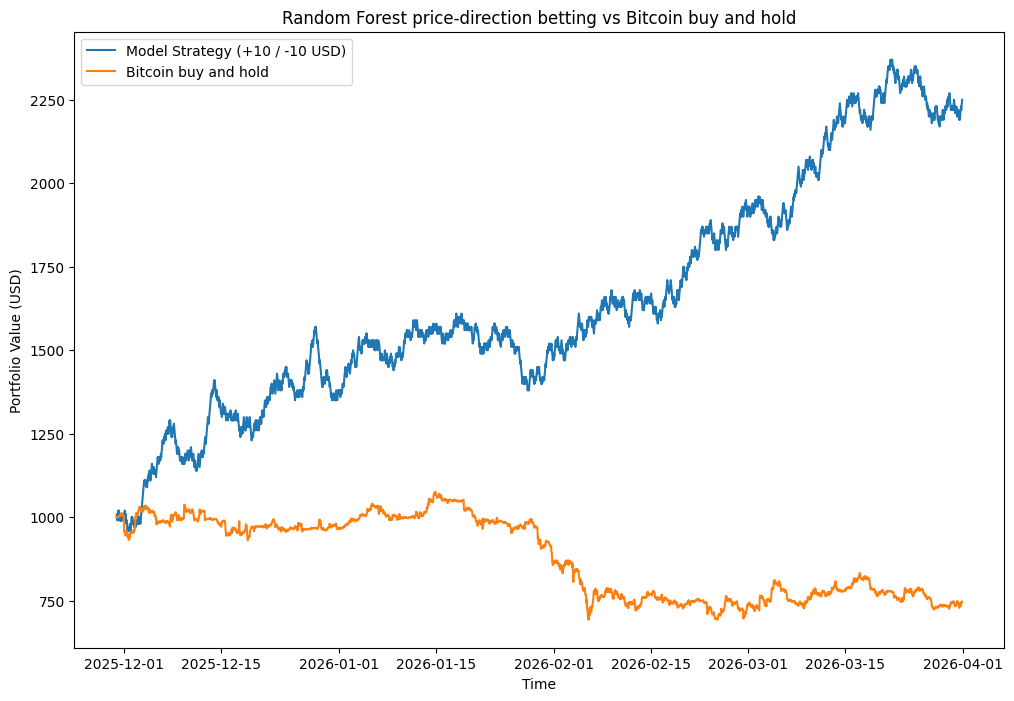

In [111]:
# Match the requested strategy: interpret predicted class 1 as UP and 0 as DOWN.
# For bin_return_d2d_close, price-direction
# betting accuracy below is therefore a different metric from its report.
# Predictions correspond to the test block after its first LAGS_NUM rows.
predictions = np.asarray(y_pred).ravel()
backtest_index = X_backtest.index[LAGS_NUM:]
if len(predictions) == 0 or len(predictions) != len(backtest_index):
    raise ValueError("Predictions must match the test samples after lag generation.")
if not np.isfinite(predictions).all():
    raise ValueError("Predictions contain non-finite values.")
if BINARY_CLASSIFICATION and not np.isin(predictions, [0, 1]).all():
    raise ValueError("Classification predictions must be labels 0 or 1.")
y_return = X_backtest.loc[backtest_index, 'return_close'].to_numpy()
signal = predictions.astype(int) if BINARY_CLASSIFICATION else (predictions > 0).astype(int)
START_CASH = 1000.0
BET_PAYOUT = 10.0
start_cash = START_CASH
cash = start_cash
movement_list = [cash]
for prediction, actual_return in zip(signal, y_return):
    if prediction == 1:
        cash += BET_PAYOUT if actual_return > 0 else -BET_PAYOUT
    else:
        cash += BET_PAYOUT if actual_return < 0 else -BET_PAYOUT
    movement_list.append(cash)
# As in the supplied example, zero price change loses for either direction.
# This fixed-stake simulation continues even if capital reaches zero.

settlement_index = backtest_index + pd.Timedelta(milliseconds=TIMEFRAME_DICT[TIMEFRAME])
curve_index = pd.DatetimeIndex([backtest_index[0]]).append(settlement_index)
strategy_curve = pd.Series(movement_list, index=curve_index, name="Model Strategy")
# Compound actual simple returns: cumsum is only an approximation to buy and hold.
buy_and_hold_curve = pd.Series(
    np.r_[start_cash, start_cash * np.cumprod(1 + y_return)],
    index=curve_index, name="Bitcoin buy and hold")

RISK_FREE_ANNUAL = 0.0
# Crypto trades 24/7: 8760 hourly periods per 365-day year.
periods_per_year = (365 * 24 * 60 * 60 * 1000) / TIMEFRAME_DICT[TIMEFRAME]

def annualized_sharpe(equity, periods_per_year, risk_free_annual=0.0):
    equity = np.asarray(equity, dtype=float)
    if (len(equity) < 3 or not np.isfinite(equity).all()
            or (equity <= 0).any()):
        return np.nan  # Percentage-return Sharpe is not reported after insolvency.
    returns = np.diff(equity) / equity[:-1]
    risk_free_per_period = np.expm1(np.log1p(risk_free_annual) / periods_per_year)
    excess_returns = returns - risk_free_per_period
    volatility = excess_returns.std(ddof=1)
    if np.isclose(volatility, 0.0):
        return np.nan
    # Conventional square-root annualization; not adjusted for autocorrelation.
    return np.sqrt(periods_per_year) * excess_returns.mean() / volatility

strategy_sharpe = annualized_sharpe(strategy_curve, periods_per_year, RISK_FREE_ANNUAL)
buy_and_hold_sharpe = annualized_sharpe(buy_and_hold_curve, periods_per_year, RISK_FREE_ANNUAL)
backtest_results = pd.DataFrame({
    "prediction": predictions,
    "predicted_direction": signal,
}, index=backtest_index)
backtest_results["price_return"] = y_return
backtest_results["pnl_usd"] = np.diff(movement_list)
backtest_results["cash"] = movement_list[1:]

print(f"Final cash: {cash:.2f}")
print(f"Total return: {(cash - start_cash) / start_cash * 100:.2f}%")
print(f"Price direction bet accuracy: {(backtest_results.pnl_usd > 0).mean():.4f}")
print(f"Strategy annualized Sharpe (risk-free={RISK_FREE_ANNUAL:.1%}): {strategy_sharpe:.4f}")
print(f"Buy and hold return: {(buy_and_hold_curve.iloc[-1] / start_cash - 1) * 100:.2f}%")
print(f"Buy and hold annualized Sharpe: {buy_and_hold_sharpe:.4f}")
if (strategy_curve <= 0).any():
    print("Strategy reached non-positive capital: Sharpe is undefined (NaN).")
plt.figure(figsize=(12, 8))
plt.plot(strategy_curve.index, strategy_curve, label="Model Strategy (+10 / -10 USD)")
plt.plot(buy_and_hold_curve.index, buy_and_hold_curve, label="Bitcoin buy and hold")
plt.xlabel("Time")
plt.ylabel("Portfolio Value (USD)")
plt.title("Random Forest price-direction betting vs Bitcoin buy and hold")
plt.legend()
plt.show()


MODEL BACKTEST RESULTS
Epsilon:                      0.001
Number of observations:       2925
Number of bets:               789
Bet frequency:                0.2697 (26.97%)
----------------------------------------------------------------------
UP bets:                      407
DOWN bets:                    382
UP accuracy:                  0.5012
DOWN accuracy:                0.5497
----------------------------------------------------------------------
Confirmed bets:               0
Confirmed accuracy:           nan
Neutral-zone bets:            789
Neutral-zone accuracy:        0.5247
----------------------------------------------------------------------
Winning bets:                 414
Losing bets:                  375
Overall bet accuracy:         0.5247 (52.47%)
----------------------------------------------------------------------
Starting cash:                1000.00 USDT
Final cash:                   1390.00 USDT
Net profit:                   390.00 USDT
Total return:       

,Strategy,Number of Bets,Bet Accuracy,Final Cash,Total Return (%),Sharpe Ratio,Bankrupt
0,Random Forest,789,0.5247,1390.0,39.0,2.7541,False
1,Momentum,2156,0.4768,0.0,-100.0,-1.5613,True
2,Random,789,0.4791,670.0,-33.0,-2.1720,False



FIRST MODEL BETS:


,previous_return,prediction,future_return,signal_type,decision,pnl_usd,cash
1,0.000545,0,0.001008,NEUTRAL,DOWN,-10.0,990.0
3,0.000213,0,-0.001296,NEUTRAL,DOWN,10.0,1000.0
6,-0.000565,1,-0.000817,NEUTRAL,UP,-10.0,990.0
7,-0.000817,1,0.001266,NEUTRAL,UP,10.0,1000.0
9,0.000764,0,0.002378,NEUTRAL,DOWN,-10.0,990.0
17,-0.000707,1,0.004264,NEUTRAL,UP,10.0,1000.0
20,-0.000309,1,0.000010,NEUTRAL,UP,10.0,1010.0
21,0.000010,1,-0.001587,NEUTRAL,UP,-10.0,1000.0
24,0.000560,0,-0.009485,NEUTRAL,DOWN,10.0,1010.0
36,-0.000659,1,-0.005754,NEUTRAL,UP,-10.0,1000.0


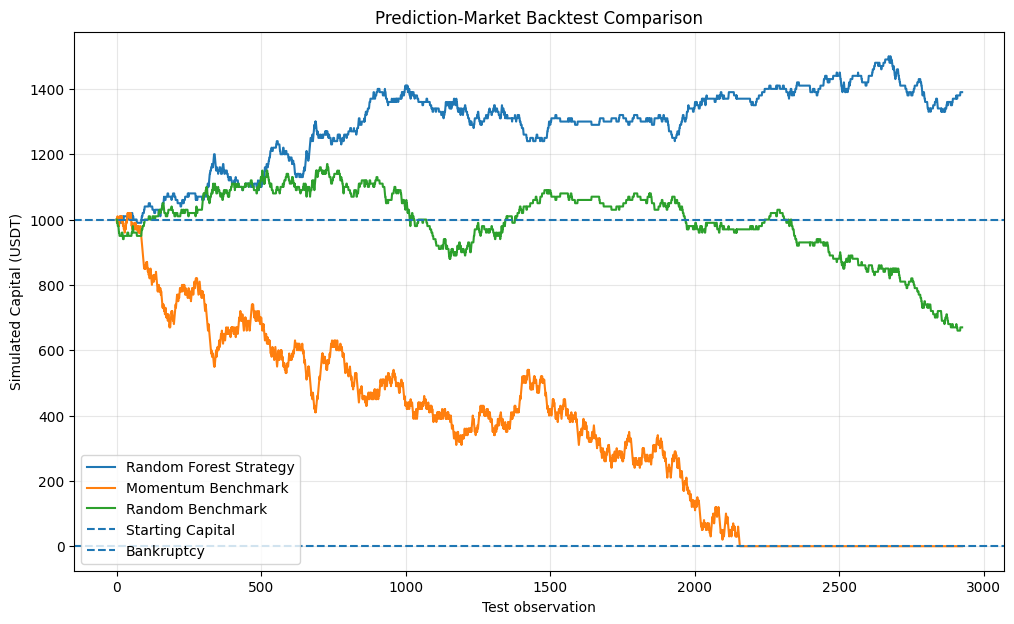

In [112]:
# ============================================================
# BACKTESTING - PREDICTION MARKET
# MODEL + MOMENTUM + RANDOM BENCHMARK
# ============================================================

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

EPSILON = 0.001

START_CASH = 1000.0
BET_PAYOUT = 10.0

RISK_FREE_ANNUAL = 0.0
RANDOM_SEED = 42


# ============================================================
# 1. PREPARE DATA
# ============================================================

predictions = np.asarray(y_pred).ravel().astype(int)

if not np.isin(predictions, [0, 1]).all():
    raise ValueError(
        "Predictions must contain only binary labels 0 and 1."
    )


# Original test returns before generate_lags()
returns = np.asarray(
    X_backtest["return_close"]
).ravel()


# For each prediction:
#
# previous_return = r[t]
# future_return   = r[t+1]
#
# First prediction is generated after LAGS_NUM observations.

previous_returns = returns[
    LAGS_NUM - 1:
    LAGS_NUM - 1 + len(predictions)
]

future_returns = returns[
    LAGS_NUM:
    LAGS_NUM + len(predictions)
]


if len(previous_returns) != len(predictions):
    raise ValueError(
        f"Previous return length mismatch: "
        f"{len(previous_returns)} vs {len(predictions)}"
    )

if len(future_returns) != len(predictions):
    raise ValueError(
        f"Future return length mismatch: "
        f"{len(future_returns)} vs {len(predictions)}"
    )


# ============================================================
# 2. MODEL STRATEGY
# ============================================================
#
# RULES:
#
# r[t] > EPSILON and prediction == 1
#       -> BET UP
#
# r[t] < -EPSILON and prediction == 0
#       -> BET DOWN
#
# |r[t]| <= EPSILON and prediction == 1
#       -> BET UP
#
# |r[t]| <= EPSILON and prediction == 0
#       -> BET DOWN
#
# Otherwise:
#       -> NO BET
#
# Settlement:
#
# UP wins   if r[t+1] > 0
# DOWN wins if r[t+1] < 0
#
# Bankruptcy:
#
# cash <= 0 -> stop betting permanently
# ============================================================

cash = START_CASH

cash_history = [cash]
pnl_history = []
decision_history = []
signal_type_history = []

bets = 0
wins = 0
losses = 0

up_bets = 0
down_bets = 0

up_wins = 0
down_wins = 0

confirmed_bets = 0
confirmed_wins = 0

neutral_bets = 0
neutral_wins = 0

bankrupt = False


for prediction, previous_return, future_return in zip(
    predictions,
    previous_returns,
    future_returns
):

    # --------------------------------------------------------
    # BANKRUPTCY
    # --------------------------------------------------------

    if bankrupt or cash <= 0:

        bankrupt = True

        pnl_history.append(0.0)
        decision_history.append("BANKRUPT")
        signal_type_history.append("BANKRUPT")

        cash_history.append(0.0)

        continue


    pnl = 0.0
    decision = "NO BET"
    signal_type = "NO BET"


    # --------------------------------------------------------
    # CLEARLY POSITIVE PREVIOUS RETURN + prediction = 1
    # -> UP
    # --------------------------------------------------------

    if previous_return > EPSILON and prediction == 1:

        decision = "UP"
        signal_type = "CONFIRMED"

        bets += 1
        confirmed_bets += 1
        up_bets += 1

        if future_return > 0:

            pnl = BET_PAYOUT

            wins += 1
            confirmed_wins += 1
            up_wins += 1

        else:

            pnl = -BET_PAYOUT
            losses += 1


    # --------------------------------------------------------
    # CLEARLY NEGATIVE PREVIOUS RETURN + prediction = 0
    # -> DOWN
    # --------------------------------------------------------

    elif previous_return < -EPSILON and prediction == 0:

        decision = "DOWN"
        signal_type = "CONFIRMED"

        bets += 1
        confirmed_bets += 1
        down_bets += 1

        if future_return < 0:

            pnl = BET_PAYOUT

            wins += 1
            confirmed_wins += 1
            down_wins += 1

        else:

            pnl = -BET_PAYOUT
            losses += 1


    # --------------------------------------------------------
    # NEUTRAL ZONE
    #
    # |r[t]| <= EPSILON
    #
    # prediction = 1 -> UP
    # prediction = 0 -> DOWN
    # --------------------------------------------------------

    elif abs(previous_return) <= EPSILON:

        signal_type = "NEUTRAL"

        bets += 1
        neutral_bets += 1


        # Prediction = 1 -> UP
        if prediction == 1:

            decision = "UP"
            up_bets += 1

            if future_return > 0:

                pnl = BET_PAYOUT

                wins += 1
                neutral_wins += 1
                up_wins += 1

            else:

                pnl = -BET_PAYOUT
                losses += 1


        # Prediction = 0 -> DOWN
        else:

            decision = "DOWN"
            down_bets += 1

            if future_return < 0:

                pnl = BET_PAYOUT

                wins += 1
                neutral_wins += 1
                down_wins += 1

            else:

                pnl = -BET_PAYOUT
                losses += 1


    # --------------------------------------------------------
    # NO BET
    # --------------------------------------------------------

    else:

        pnl = 0.0


    # --------------------------------------------------------
    # BANKRUPTCY PROTECTION
    # --------------------------------------------------------
    #
    # Strategy cannot lose more money than currently available.
    #

    if pnl < 0:

        pnl = -min(
            abs(pnl),
            cash
        )


    cash += pnl

    cash = max(
        cash,
        0.0
    )


    if cash <= 0:
        bankrupt = True


    pnl_history.append(pnl)
    decision_history.append(decision)
    signal_type_history.append(signal_type)

    cash_history.append(cash)


# ============================================================
# 3. MODEL STATISTICS
# ============================================================

number_of_observations = len(predictions)

bet_frequency = (
    bets / number_of_observations
    if number_of_observations > 0
    else np.nan
)

bet_accuracy = (
    wins / bets
    if bets > 0
    else np.nan
)

up_accuracy = (
    up_wins / up_bets
    if up_bets > 0
    else np.nan
)

down_accuracy = (
    down_wins / down_bets
    if down_bets > 0
    else np.nan
)

confirmed_accuracy = (
    confirmed_wins / confirmed_bets
    if confirmed_bets > 0
    else np.nan
)

neutral_accuracy = (
    neutral_wins / neutral_bets
    if neutral_bets > 0
    else np.nan
)

net_profit = (
    cash - START_CASH
)

total_return = (
    net_profit / START_CASH
) * 100


# ============================================================
# 4. SHARPE RATIO FUNCTION
# ============================================================

periods_per_year = (
    (365 * 24 * 60 * 60 * 1000)
    / TIMEFRAME_DICT[TIMEFRAME]
)


def annualized_sharpe(
    equity,
    periods_per_year,
    risk_free_annual=0.0
):

    equity = np.asarray(
        equity,
        dtype=float
    )

    if len(equity) < 3:
        return np.nan

    if not np.isfinite(equity).all():
        return np.nan

    # Calculate returns only while capital is positive
    valid_returns = []

    for previous_cash, current_cash in zip(
        equity[:-1],
        equity[1:]
    ):

        if previous_cash <= 0:
            break

        valid_returns.append(
            (current_cash - previous_cash)
            / previous_cash
        )


    returns_array = np.asarray(
        valid_returns,
        dtype=float
    )


    if len(returns_array) < 2:
        return np.nan


    risk_free_per_period = np.expm1(
        np.log1p(risk_free_annual)
        / periods_per_year
    )


    excess_returns = (
        returns_array
        - risk_free_per_period
    )


    volatility = excess_returns.std(
        ddof=1
    )


    if np.isclose(
        volatility,
        0.0
    ):
        return np.nan


    return (
        np.sqrt(periods_per_year)
        * excess_returns.mean()
        / volatility
    )


strategy_sharpe = annualized_sharpe(
    cash_history,
    periods_per_year,
    RISK_FREE_ANNUAL
)


# ============================================================
# 5. MOMENTUM BENCHMARK
# ============================================================
#
# No model is used.
#
# r[t] > 0 -> UP
# r[t] < 0 -> DOWN
#
# Bankruptcy at 0 USDT.
# ============================================================

momentum_cash = START_CASH

momentum_cash_history = [
    momentum_cash
]

momentum_bets = 0
momentum_wins = 0
momentum_losses = 0

momentum_bankrupt = False


for previous_return, future_return in zip(
    previous_returns,
    future_returns
):

    # --------------------------------------------------------
    # BANKRUPTCY
    # --------------------------------------------------------

    if momentum_bankrupt or momentum_cash <= 0:

        momentum_bankrupt = True

        momentum_cash_history.append(
            0.0
        )

        continue


    pnl = 0.0


    # --------------------------------------------------------
    # MOMENTUM UP
    # --------------------------------------------------------

    if previous_return > 0:

        momentum_bets += 1

        if future_return > 0:

            pnl = BET_PAYOUT
            momentum_wins += 1

        else:

            pnl = -BET_PAYOUT
            momentum_losses += 1


    # --------------------------------------------------------
    # MOMENTUM DOWN
    # --------------------------------------------------------

    elif previous_return < 0:

        momentum_bets += 1

        if future_return < 0:

            pnl = BET_PAYOUT
            momentum_wins += 1

        else:

            pnl = -BET_PAYOUT
            momentum_losses += 1


    # --------------------------------------------------------
    # EXACTLY ZERO -> NO BET
    # --------------------------------------------------------

    else:

        pnl = 0.0


    # --------------------------------------------------------
    # BANKRUPTCY PROTECTION
    # --------------------------------------------------------

    if pnl < 0:

        pnl = -min(
            abs(pnl),
            momentum_cash
        )


    momentum_cash += pnl

    momentum_cash = max(
        momentum_cash,
        0.0
    )


    if momentum_cash <= 0:
        momentum_bankrupt = True


    momentum_cash_history.append(
        momentum_cash
    )


momentum_accuracy = (
    momentum_wins / momentum_bets
    if momentum_bets > 0
    else np.nan
)

momentum_return = (
    (momentum_cash - START_CASH)
    / START_CASH
) * 100


momentum_sharpe = annualized_sharpe(
    momentum_cash_history,
    periods_per_year,
    RISK_FREE_ANNUAL
)


# ============================================================
# 6. RANDOM BENCHMARK
# ============================================================
#
# Random strategy bets only when the MODEL strategy
# would place a bet.
#
# Random direction:
#
# 1 -> UP
# 0 -> DOWN
#
# Fixed seed ensures reproducibility.
#
# Bankruptcy at 0 USDT.
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)

random_cash = START_CASH

random_cash_history = [
    random_cash
]

random_bets = 0
random_wins = 0
random_losses = 0

random_bankrupt = False


for model_decision, future_return in zip(
    decision_history,
    future_returns
):

    # --------------------------------------------------------
    # BANKRUPTCY
    # --------------------------------------------------------

    if random_bankrupt or random_cash <= 0:

        random_bankrupt = True

        random_cash_history.append(
            0.0
        )

        continue


    pnl = 0.0


    # --------------------------------------------------------
    # RANDOM BET
    # --------------------------------------------------------

    if model_decision in ["UP", "DOWN"]:

        random_bets += 1

        random_prediction = rng.integers(
            0,
            2
        )


        # Random UP
        if random_prediction == 1:

            if future_return > 0:

                pnl = BET_PAYOUT
                random_wins += 1

            else:

                pnl = -BET_PAYOUT
                random_losses += 1


        # Random DOWN
        else:

            if future_return < 0:

                pnl = BET_PAYOUT
                random_wins += 1

            else:

                pnl = -BET_PAYOUT
                random_losses += 1


    # --------------------------------------------------------
    # NO BET
    # --------------------------------------------------------

    else:

        pnl = 0.0


    # --------------------------------------------------------
    # BANKRUPTCY PROTECTION
    # --------------------------------------------------------

    if pnl < 0:

        pnl = -min(
            abs(pnl),
            random_cash
        )


    random_cash += pnl

    random_cash = max(
        random_cash,
        0.0
    )


    if random_cash <= 0:
        random_bankrupt = True


    random_cash_history.append(
        random_cash
    )


random_accuracy = (
    random_wins / random_bets
    if random_bets > 0
    else np.nan
)

random_return = (
    (random_cash - START_CASH)
    / START_CASH
) * 100


random_sharpe = annualized_sharpe(
    random_cash_history,
    periods_per_year,
    RISK_FREE_ANNUAL
)


# ============================================================
# 7. DETAILED MODEL RESULTS
# ============================================================

print()
print("=" * 70)
print("MODEL BACKTEST RESULTS")
print("=" * 70)

print(
    f"Epsilon:                      "
    f"{EPSILON}"
)

print(
    f"Number of observations:       "
    f"{number_of_observations}"
)

print(
    f"Number of bets:               "
    f"{bets}"
)

print(
    f"Bet frequency:                "
    f"{bet_frequency:.4f} "
    f"({bet_frequency * 100:.2f}%)"
)

print("-" * 70)

print(
    f"UP bets:                      "
    f"{up_bets}"
)

print(
    f"DOWN bets:                    "
    f"{down_bets}"
)

print(
    f"UP accuracy:                  "
    f"{up_accuracy:.4f}"
)

print(
    f"DOWN accuracy:                "
    f"{down_accuracy:.4f}"
)

print("-" * 70)

print(
    f"Confirmed bets:               "
    f"{confirmed_bets}"
)

print(
    f"Confirmed accuracy:           "
    f"{confirmed_accuracy:.4f}"
)

print(
    f"Neutral-zone bets:            "
    f"{neutral_bets}"
)

print(
    f"Neutral-zone accuracy:        "
    f"{neutral_accuracy:.4f}"
)

print("-" * 70)

print(
    f"Winning bets:                 "
    f"{wins}"
)

print(
    f"Losing bets:                  "
    f"{losses}"
)

print(
    f"Overall bet accuracy:         "
    f"{bet_accuracy:.4f} "
    f"({bet_accuracy * 100:.2f}%)"
)

print("-" * 70)

print(
    f"Starting cash:                "
    f"{START_CASH:.2f} USDT"
)

print(
    f"Final cash:                   "
    f"{cash:.2f} USDT"
)

print(
    f"Net profit:                   "
    f"{net_profit:.2f} USDT"
)

print(
    f"Total return:                 "
    f"{total_return:.2f}%"
)

print(
    f"Sharpe ratio:                 "
    f"{strategy_sharpe:.4f}"
)

print(
    f"Bankrupt:                     "
    f"{bankrupt}"
)

print("=" * 70)


# ============================================================
# 8. COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Strategy": [
        "Random Forest",
        "Momentum",
        "Random"
    ],

    "Number of Bets": [
        bets,
        momentum_bets,
        random_bets
    ],

    "Bet Accuracy": [
        bet_accuracy,
        momentum_accuracy,
        random_accuracy
    ],

    "Final Cash": [
        cash,
        momentum_cash,
        random_cash
    ],

    "Total Return (%)": [
        total_return,
        momentum_return,
        random_return
    ],

    "Sharpe Ratio": [
        strategy_sharpe,
        momentum_sharpe,
        random_sharpe
    ],

    "Bankrupt": [
        bankrupt,
        momentum_bankrupt,
        random_bankrupt
    ]

})


comparison_display = comparison.copy()

comparison_display["Bet Accuracy"] = (
    comparison_display["Bet Accuracy"]
    .round(4)
)

comparison_display["Final Cash"] = (
    comparison_display["Final Cash"]
    .round(2)
)

comparison_display["Total Return (%)"] = (
    comparison_display["Total Return (%)"]
    .round(2)
)

comparison_display["Sharpe Ratio"] = (
    comparison_display["Sharpe Ratio"]
    .round(4)
)


print()
print("=" * 80)
print("BACKTEST COMPARISON")
print("=" * 80)

display(
    comparison_display
)


# ============================================================
# 9. DETAILED RESULTS DATAFRAME
# ============================================================

backtest_results = pd.DataFrame({

    "previous_return": previous_returns,

    "prediction": predictions,

    "future_return": future_returns,

    "signal_type": signal_type_history,

    "decision": decision_history,

    "pnl_usd": pnl_history,

    "cash": cash_history[1:]

})


print()
print("FIRST MODEL BETS:")

display(
    backtest_results[
        backtest_results["decision"].isin(
            ["UP", "DOWN"]
        )
    ].head(20)
)


# ============================================================
# 10. EQUITY CURVES
# ============================================================

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    cash_history,
    label="Random Forest Strategy"
)

plt.plot(
    momentum_cash_history,
    label="Momentum Benchmark"
)

plt.plot(
    random_cash_history,
    label="Random Benchmark"
)

plt.axhline(
    y=START_CASH,
    linestyle="--",
    label="Starting Capital"
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Bankruptcy"
)

plt.xlabel(
    "Test observation"
)

plt.ylabel(
    "Simulated Capital (USDT)"
)

plt.title(
    "Prediction-Market Backtest Comparison"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()